# Ridge, Lasso ve Elastic Net Regresyon
Bu notebook; **Ridge**, **Lasso** ve **Elastic Net** regresyon modellerini
scikit-learn kütüphanesi ile adım adım uygular ve karşılaştırır.

Kullanılan veri seti: `Residential-Building-Data-Set` (İnşaat projelerine ait
fiziksel, finansal ve ekonomik göstergeler ile gerçek satış fiyatı).

**İçerik:**
1. Kütüphanelerin yüklenmesi
2. Veri setinin yüklenmesi ve incelenmesi
3. Eğitim / test ayrımı ve ölçekleme
4. Ridge Regresyon
5. Lasso Regresyon
6. Elastic Net Regresyon
7. Model karşılaştırması (metrikler ve grafik)
8. GridSearchCV ile hiperparametre optimizasyonu
9. Katsayıların yorumlanması (özellik önemi)

## 1. Gerekli Kütüphanelerin Yüklenmesi

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

np.random.seed(42)

## 2. Veri Setinin Yüklenmesi ve İncelenmesi
Veri seti; projenin başlangıç/bitiş tarihleri, fiziksel ve finansal
değişkenler ile 5 farklı zaman gecikmesindeki (lag) ekonomik göstergeler
olmak üzere **107 özellik** ile projenin gerçek satış fiyatını
(**hedef değişken: V-9**) içerir.

In [2]:
df = pd.read_excel('Residential-Building-Data-Set.xlsx', header=1)

X = df.drop(columns=['V-9', 'V-10'])
y = df['V-9']

print("Özellik sayısı:", X.shape[1])
print("Gözlem sayısı :", X.shape[0])
X.head()

Özellik sayısı: 107
Gözlem sayısı : 372


,START YEAR,START QUARTER,COMPLETION YEAR,COMPLETION QUARTER,V-1,V-2,V-3,V-4,V-5,V-6,...,V-20.4,V-21.4,V-22.4,V-23.4,V-24.4,V-25.4,V-26.4,V-27.4,V-28.4,V-29.4
0,81,1,85,1,1,3150.0,920.0,598.5,190,1010.84,...,15,733.800000,815.50,1755.00,8002.0,60.74,54.26,2978.26,41407.0,601988.1
1,84,1,89,4,1,7600.0,1140.0,3040.0,400,963.81,...,15,1143.800000,1316.30,8364.78,8393.0,90.95,89.79,11379.37,44835.0,929027.1
2,78,1,81,4,1,4800.0,840.0,480.0,100,689.84,...,15,589.500000,765.80,1755.00,4930.0,38.70,32.04,1653.06,37933.0,377828.6
3,72,2,73,2,1,685.0,202.0,13.7,20,459.54,...,12,197.679557,152.25,1442.31,1456.0,9.73,8.34,686.16,8194.0,122031.7
4,87,1,90,2,1,3000.0,800.0,1230.0,410,631.91,...,14,2220.600000,2244.10,9231.76,9286.0,136.60,140.20,9821.00,48260.0,1734973.5


In [3]:
y.describe()

count     372.000000
mean     1387.432796
std      1206.083047
min        50.000000
25%       577.500000
50%      1000.000000
75%      1700.000000
max      6800.000000
Name: V-9, dtype: float64

## 3. Eğitim / Test Ayrımı ve Özellik Ölçekleme
Ridge, Lasso ve Elastic Net; katsayılara **ceza (penalty)** uyguladığı için
özelliklerin aynı ölçekte olması çok önemlidir. Bu nedenle `StandardScaler`
ile veriyi standartlaştırıyoruz (ortalama=0, standart sapma=1).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu  :", X_test.shape)

Eğitim seti boyutu: (297, 107)
Test seti boyutu  : (75, 107)


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled.head()

,START YEAR,START QUARTER,COMPLETION YEAR,COMPLETION QUARTER,V-1,V-2,V-3,V-4,V-5,V-6,...,V-20.4,V-21.4,V-22.4,V-23.4,V-24.4,V-25.4,V-26.4,V-27.4,V-28.4,V-29.4
0,-2.062646,-0.197880,-2.165593,0.408986,-0.298734,-0.639621,-0.507097,-0.520177,-1.165950,0.339716,...,-2.319593,-1.299843,-1.365672,-1.055400,-2.689634,-1.638973,-1.444970,-1.276956,-1.428092,-1.452005
1,-2.062646,1.638693,-1.923613,-0.477648,-1.064919,-0.601803,-0.526700,-0.516633,-1.165950,0.261003,...,-2.319593,-1.319346,-1.357070,-1.042715,-2.638576,-1.613720,-1.422674,-1.285978,-0.163126,-1.424971
2,-1.331322,1.638693,-1.197675,-1.364282,-1.064919,0.008696,0.041805,-0.343985,-0.811420,-0.107132,...,0.492322,-0.964935,-0.580408,-1.015100,-1.305960,-1.136969,-1.127549,-0.901470,0.009788,-0.912279
3,1.106425,-0.197880,0.980138,0.408986,1.540107,-0.174994,-0.115024,-0.222305,-0.190993,-0.986919,...,-0.444983,1.017386,0.927513,1.083901,0.800417,1.131740,1.126575,0.880381,-1.155984,1.584190
4,1.106425,0.720407,0.980138,1.295621,-1.371392,-0.126370,-0.075817,0.513514,2.379349,0.611666,...,-0.444983,1.355667,1.192041,1.092928,0.818984,1.211581,1.250463,0.862623,-0.251392,1.558704


## 4. Ridge Regresyon (L2 Regularizasyon)
Ridge, katsayıların **karelerinin toplamına** (L2 normu) ceza uygular.
Bu, katsayıları sıfıra yaklaştırır ama tam olarak sıfırlamaz; yani tüm
özellikler modelde kalır. `alpha` parametresi ceza şiddetini kontrol eder.

In [6]:
ridge_model = Ridge(alpha=1.0, random_state=42)

ridge_model.fit(X_train_scaled, y_train)

y_pred_ridge = ridge_model.predict(X_test_scaled)

ridge_mse = mean_squared_error(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)
ridge_r2 = r2_score(y_test, y_pred_ridge)

print(f"Ridge  -> MSE: {ridge_mse:.2f} | MAE: {ridge_mae:.2f} | R2: {ridge_r2:.4f}")

Ridge  -> MSE: 27813.25 | MAE: 109.54 | R2: 0.9849


## 5. Lasso Regresyon (L1 Regularizasyon)
Lasso, katsayıların **mutlak değerlerinin toplamına** (L1 normu) ceza
uygular. Bu özelliği sayesinde önemsiz katsayıları **tam olarak sıfıra**
çekebilir; yani otomatik özellik seçimi (feature selection) yapar.

In [7]:
lasso_model = Lasso(alpha=0.1, random_state=42, max_iter=10000)

lasso_model.fit(X_train_scaled, y_train)

y_pred_lasso = lasso_model.predict(X_test_scaled)

lasso_mse = mean_squared_error(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)
lasso_r2 = r2_score(y_test, y_pred_lasso)

print(f"Lasso  -> MSE: {lasso_mse:.2f} | MAE: {lasso_mae:.2f} | R2: {lasso_r2:.4f}")

n_sifir_katsayi = np.sum(lasso_model.coef_ == 0)
print(f"Lasso tarafından sıfırlanan özellik sayısı: {n_sifir_katsayi} / {len(lasso_model.coef_)}")

Lasso  -> MSE: 27467.14 | MAE: 109.21 | R2: 0.9850
Lasso tarafından sıfırlanan özellik sayısı: 41 / 107


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.623e+05, tolerance: 3.977e+04
  model = cd_fast.enet_coordinate_descent(


## 6. Elastic Net Regresyon (L1 + L2 Kombinasyonu)
Elastic Net, Ridge (L2) ve Lasso (L1) cezalarını birlikte kullanır.
`l1_ratio` parametresi bu iki ceza arasındaki dengeyi belirler:
- `l1_ratio=1` → saf Lasso
- `l1_ratio=0` → saf Ridge
- `0 < l1_ratio < 1` → ikisinin karışımı

In [8]:
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42, max_iter=10000)

elastic_model.fit(X_train_scaled, y_train)

y_pred_elastic = elastic_model.predict(X_test_scaled)

elastic_mse = mean_squared_error(y_test, y_pred_elastic)
elastic_mae = mean_absolute_error(y_test, y_pred_elastic)
elastic_r2 = r2_score(y_test, y_pred_elastic)

print(f"ElasticNet -> MSE: {elastic_mse:.2f} | MAE: {elastic_mae:.2f} | R2: {elastic_r2:.4f}")

ElasticNet -> MSE: 40513.72 | MAE: 139.83 | R2: 0.9779


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.897e+05, tolerance: 3.977e+04
  model = cd_fast.enet_coordinate_descent(


## 7. Model Karşılaştırması

In [9]:
sonuclar = pd.DataFrame({
    "Model": ["Ridge", "Lasso", "ElasticNet"],
    "MSE": [ridge_mse, lasso_mse, elastic_mse],
    "MAE": [ridge_mae, lasso_mae, elastic_mae],
    "R2": [ridge_r2, lasso_r2, elastic_r2]
})

sonuclar = sonuclar.sort_values("R2", ascending=False)
sonuclar

,Model,MSE,MAE,R2
1,Lasso,27467.135357,109.214430,0.985043
0,Ridge,27813.246429,109.537114,0.984855
2,ElasticNet,40513.720075,139.831190,0.977939


In [10]:
katsayilar = pd.DataFrame({
    "Özellik": X.columns,
    "Ridge": ridge_model.coef_,
    "Lasso": lasso_model.coef_,
    "ElasticNet": elastic_model.coef_
})

katsayilar

,Özellik,Ridge,Lasso,ElasticNet
0,START YEAR,-8.031489,0.000000,6.869899
1,START QUARTER,34.128498,76.692269,-4.476522
2,COMPLETION YEAR,0.832596,0.000000,13.728853
3,COMPLETION QUARTER,29.299360,31.586851,17.264810
4,V-1,-39.580357,-31.007855,-100.473046
...,...,...,...,...
102,V-25.4,0.578476,0.000000,4.855904
103,V-26.4,5.452349,0.000000,5.372799
104,V-27.4,72.544708,156.683494,42.597039
105,V-28.4,8.163522,14.703226,7.351492


Özellik sayısı (107) tüm katsayıları tek bir grafikte okunabilir şekilde
göstermek için fazla olduğundan, üç modelin ortalama mutlak katsayı
büyüklüğüne göre **en etkili 15 özellik** seçilerek görselleştirilmiştir.

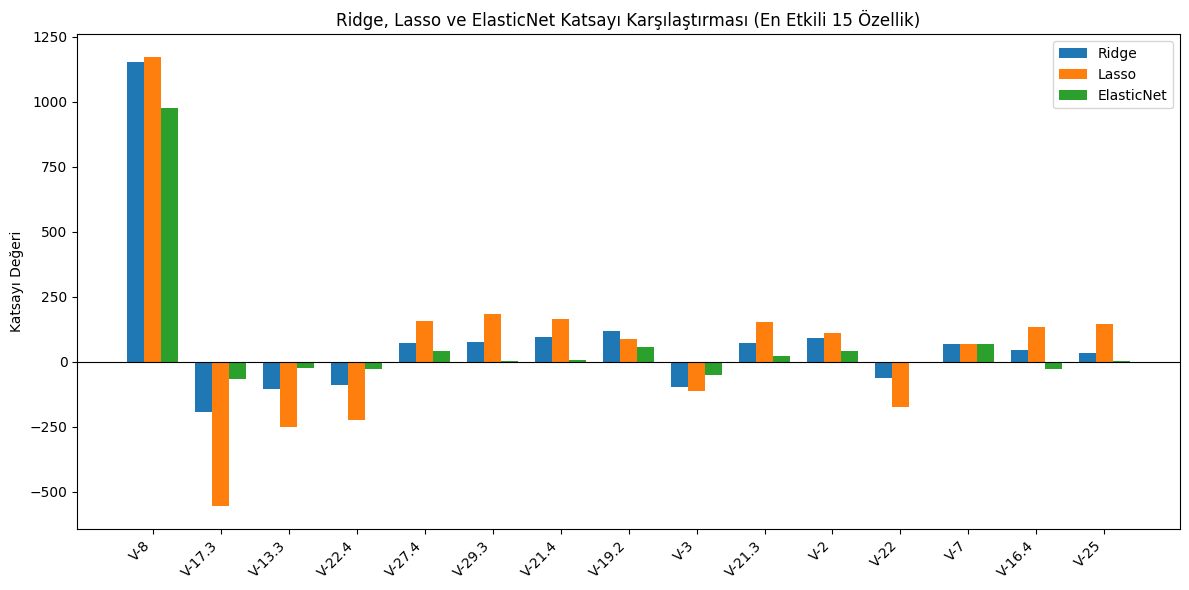

In [11]:
katsayilar["Ortalama_Etki"] = katsayilar[["Ridge", "Lasso", "ElasticNet"]].abs().mean(axis=1)
en_etkili = katsayilar.sort_values("Ortalama_Etki", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))

genislik = 0.25
x_konum = np.arange(len(en_etkili))

ax.bar(x_konum - genislik, en_etkili["Ridge"], width=genislik, label="Ridge")
ax.bar(x_konum, en_etkili["Lasso"], width=genislik, label="Lasso")
ax.bar(x_konum + genislik, en_etkili["ElasticNet"], width=genislik, label="ElasticNet")

ax.set_xticks(x_konum)
ax.set_xticklabels(en_etkili["Özellik"], rotation=45, ha="right")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Katsayı Değeri")
ax.set_title("Ridge, Lasso ve ElasticNet Katsayı Karşılaştırması (En Etkili 15 Özellik)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. GridSearchCV ile Hiperparametre Optimizasyonu
Şimdiye kadar `alpha` değerlerini elle seçtik. Şimdi çapraz doğrulama
(cross-validation) kullanarak her model için en iyi `alpha` (ve Elastic Net
için `l1_ratio`) değerini otomatik olarak bulalım.

In [12]:
alpha_araligi = {"alpha": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]}

ridge_grid = GridSearchCV(
    Ridge(random_state=42),
    param_grid=alpha_araligi,
    cv=5,
    scoring="r2"
)
ridge_grid.fit(X_train_scaled, y_train)

lasso_grid = GridSearchCV(
    Lasso(random_state=42, max_iter=10000),
    param_grid=alpha_araligi,
    cv=5,
    scoring="r2"
)
lasso_grid.fit(X_train_scaled, y_train)

elastic_araligi = {
    "alpha": [0.001, 0.01, 0.1, 1.0, 10.0],
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_grid = GridSearchCV(
    ElasticNet(random_state=42, max_iter=10000),
    param_grid=elastic_araligi,
    cv=5,
    scoring="r2"
)
elastic_grid.fit(X_train_scaled, y_train)

print("En iyi Ridge alpha       :", ridge_grid.best_params_)
print("En iyi Lasso alpha       :", lasso_grid.best_params_)
print("En iyi ElasticNet params :", elastic_grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.621e+06, tolerance: 2.947e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.067e+06, tolerance: 3.280e+04
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.837e+06, tolerance: 3.289e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.665e+06, tolerance: 3.239e+04
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.547e+06, tolerance: 3.151e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.013e+06, tolerance: 2.947e+04
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.538e+05, tolerance: 3.280e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.201e+06, tolerance: 3.289e+04
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.788e+05, tolerance: 3.239e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 9.561e+05, tolerance: 3.151e+04
  model = cd_fast.enet_coordinate_descent(


...

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.098e+05, tolerance: 2.947e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.394e+06, tolerance: 3.280e+04
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.596e+05, tolerance: 3.289e+04
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.671e+05, tolerance: 3.239e+04
  model = cd_fast.enet_coordinate_descent(


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.443e+05, tolerance: 3.151e+04
  model = cd_fast.enet_coordinate_descent(


En iyi Ridge alpha       : {'alpha': 1.0}
En iyi Lasso alpha       : {'alpha': 10.0}
En iyi ElasticNet params : {'alpha': 0.1, 'l1_ratio': 0.9}


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.340e+05, tolerance: 3.977e+04
  model = cd_fast.enet_coordinate_descent(


In [13]:
en_iyi_ridge = ridge_grid.best_estimator_
en_iyi_lasso = lasso_grid.best_estimator_
en_iyi_elastic = elastic_grid.best_estimator_

for isim, model in [("Ridge (optimize)", en_iyi_ridge),
                     ("Lasso (optimize)", en_iyi_lasso),
                     ("ElasticNet (optimize)", en_iyi_elastic)]:
    tahmin = model.predict(X_test_scaled)
    r2 = r2_score(y_test, tahmin)
    mse = mean_squared_error(y_test, tahmin)
    print(f"{isim:22s} -> R2: {r2:.4f} | MSE: {mse:.2f}")

Ridge (optimize)       -> R2: 0.9849 | MSE: 27813.25
Lasso (optimize)       -> R2: 0.9819 | MSE: 33293.36
ElasticNet (optimize)  -> R2: 0.9842 | MSE: 28981.82


## 9. Genel Değerlendirme

- **Ridge**: Tüm özellikleri modelde tutar, çoklu doğrusal bağlantı
  (multicollinearity) sorunu olduğunda güçlü ve kararlı sonuç verir.
  107 özellik arasında (özellikle 5 farklı zaman gecikmesindeki benzer
  ekonomik göstergeler) yüksek korelasyon beklendiğinden Ridge burada
  özellikle faydalıdır.
- **Lasso**: Önemsiz özellikleri sıfırlayarak hem regresyon hem de
  özellik seçimi yapar; 107 özellikten hangilerinin gerçekten satış
  fiyatını etkilediğini görmek için yorumlanabilirliği yüksek modeller üretir.
- **Elastic Net**: Ridge ve Lasso'nun avantajlarını `l1_ratio` ile
  dengeleyerek birleştirir; özellikle birbiriyle ilişkili çok sayıda
  özellik (bu veri setindeki lag'li ekonomik göstergeler gibi) olduğunda
  tercih edilir.

`GridSearchCV` ile bulunan optimum hiperparametreler, elle seçilen
`alpha=1.0` / `alpha=0.1` değerlerine kıyasla genellikle daha iyi
genelleme performansı (test R2) sağlar.